In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
print(jax.devices())

[CudaDevice(id=0), CudaDevice(id=1)]


In [3]:
import numpy as np
import scanpy as sc
import sys
import pickle

sys.path.append('../../scripts')
from utils import set_seed
from benchmark_pipeline import bluishgray_to_blue, gray_to_red, plot_results_table, blue_cmap, red_cmap
from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection

/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
set_seed(0)

In [5]:
slide_ids = ["221", "231", "232"] # Computed mintflow on these slides - check train_mintflow_joint.py
adata_base_path = "/data/a330d/datasets/crc/processed"

In [6]:
adata = sc.read(
    f"{adata_base_path}/crc_cosmx_wt_benchmark.h5ad"
)

In [7]:
adata.obs.sid = adata.obs.sid.astype(str)

In [8]:
adata = adata[adata.obs.sid.isin(slide_ids)].copy()

In [9]:
adata

AnnData object with n_obs × n_vars = 683989 × 2000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'version', 'dualfiles', 'Run_name', 'Run_Tissue_name', 'ISH.concentration', 'Dash', 'tissue', 'Panel', 'assay_type', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile

In [10]:
fname = "/data/a330d/data/ood/trained/mintflow_joint/predictions_epoch_30.pkl"

with open(fname, "rb") as f:
    mintflow_preds = pickle.load(f)

In [11]:
mintflow_preds.keys()

dict_keys(['TissueSection 0 (zero-based)', 'TissueSection 1 (zero-based)', 'TissueSection 2 (zero-based)'])

In [14]:
mintflow_basal = None
mintflow_spatial = None

for i, _ in enumerate(slide_ids):
    # Check if size matches - correct latents for cells
    if mintflow_preds[f'TissueSection {i} (zero-based)']['MintFlow_Z'].shape[0] == adata[adata.obs.sid == slide_ids[i]].shape[0]:
        pass
    else:
        raise ValueError(f"Size mismatch for slide {slide_ids[i]}")
    # Put Mintflow_Z in basal and MintFlow_S_out in spatial - do numpy stacking to combine results across slides
    if mintflow_basal is None:
        mintflow_basal = mintflow_preds[f'TissueSection {i} (zero-based)']['MintFlow_Z']
    else:
        mintflow_basal = np.vstack((mintflow_basal, mintflow_preds[f'TissueSection {i} (zero-based)']['MintFlow_Z']))
    
    if mintflow_spatial is None:
        mintflow_spatial = mintflow_preds[f'TissueSection {i} (zero-based)']['MintFlow_S_out']
    else:
        mintflow_spatial = np.vstack((mintflow_spatial, mintflow_preds[f'TissueSection {i} (zero-based)']['MintFlow_S_out']))

In [15]:
adata.obsm['mintflow_basal'] = mintflow_basal
adata.obsm['mintflow_spatial'] = mintflow_spatial

In [16]:
OBSM_KEYS = ['mintflow_basal', 'mintflow_spatial']
print(OBSM_KEYS)

['mintflow_basal', 'mintflow_spatial']


In [17]:
batch_key = 'sid'
celltype_key = 'coarse_type'
niche_key = 'typ_clean'

In [18]:
from numpy.random import default_rng
rng = default_rng(0)
max_cells = 100_000
if adata.n_obs > max_cells:
    adata = adata[rng.choice(adata.n_obs, max_cells, replace=False)].copy()

<Axes: ylabel='Count'>

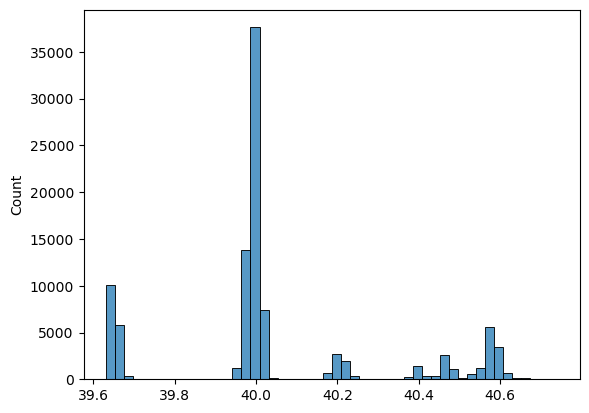

In [19]:
import seaborn as sns

sns.histplot(adata.obsm['mintflow_basal'].sum(axis=1), bins=50)

## Benchmark

In [26]:
dataset_name = "crc_mintflow_joint"

In [20]:
bm = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=celltype_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=24,
)
bm.benchmark()

/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(
Embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

INFO     8 clusters consist of a single batch or are too small. Skip.                                              


/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_kbet.py:212: RuntimeWarning: Mean of empty slice
  final_score = np.nanmean(kbet_scores["kBET"])
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  50%|█████     | 1/2 [00:19<00:19, 19.21s/it]

INFO     8 clusters consist of a single batch or are too small. Skip.                                              


/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_kbet.py:212: RuntimeWarning: Mean of empty slice
  final_score = np.nanmean(kbet_scores["kBET"])
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings: 100%|██████████| 2/2 [00:28<00:00, 14.01s/it]


In [27]:
# bm.get_results().to_csv('scib_ct.csv')
basal_df = bm.get_results()
basal_df = basal_df.rename({"Bio conservation": "Cell-type Total"}, axis=1)
basal_df.to_csv(f"../../results/{dataset_name}_scib_ct.csv")

/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/sklearn/utils/_array_api.py:686: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/sklearn/utils/_array_api.py:706: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/benchmark/_core.py:291: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Aggregate score' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df.loc[_METRIC_TYPE, per_class_score.columns] = _AGGREGATE_SCORE
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/benchmark/_core.py:291: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in 

/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


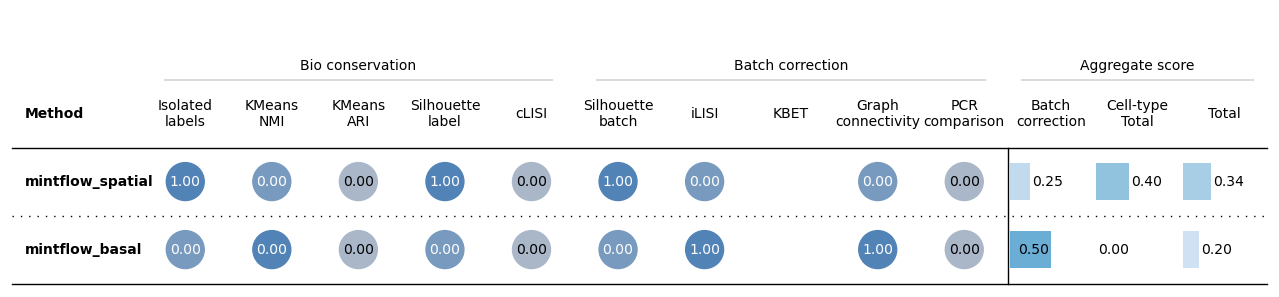

In [22]:
plot_results_table(basal_df, metric_cmap=bluishgray_to_blue, score_cmap=blue_cmap, sort_col="Cell-type Total")

## Niche

In [23]:
bm_niche = Benchmarker(
    adata,
    batch_key=batch_key,
    label_key=niche_key,
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=OBSM_KEYS,
    n_jobs=24,
)
bm_niche.benchmark()

/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scanpy/preprocessing/_pca/__init__.py:226: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  mask_var_param, mask_var = _handle_mask_var(


Embeddings:   0%|          | 0/2 [00:00<?, ?it/s]

INFO     3 clusters consist of a single batch or are too small. Skip.                                              


/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_kbet.py:212: RuntimeWarning: Mean of empty slice
  final_score = np.nanmean(kbet_scores["kBET"])
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings:  50%|█████     | 1/2 [00:10<00:10, 10.64s/it]

INFO     3 clusters consist of a single batch or are too small. Skip.                                              


/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_kbet.py:212: RuntimeWarning: Mean of empty slice
  final_score = np.nanmean(kbet_scores["kBET"])
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_graph_connectivity.py:32: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(comps)
/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/scib_metrics/metrics/_pcr_comparison.py:49: UserWarning: PCR comparison score is negative, meaning variance contribution increased after integration. Setting to 0.
  warnings.warn(
Embeddings: 100%|██████████| 2/2 [00:19<00:00,  9.61s/it]


In [28]:
omega_df = bm_niche.get_results(min_max_scale=False, clean_names=True)
omega_df = omega_df.rename({"Bio conservation":"Niche Total"}, axis=1)

omega_df.to_csv(f"../../results/{dataset_name}_scib_niche.csv")

/data/a330d/miniforge3/envs/benchmark-gpu/lib/python3.10/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


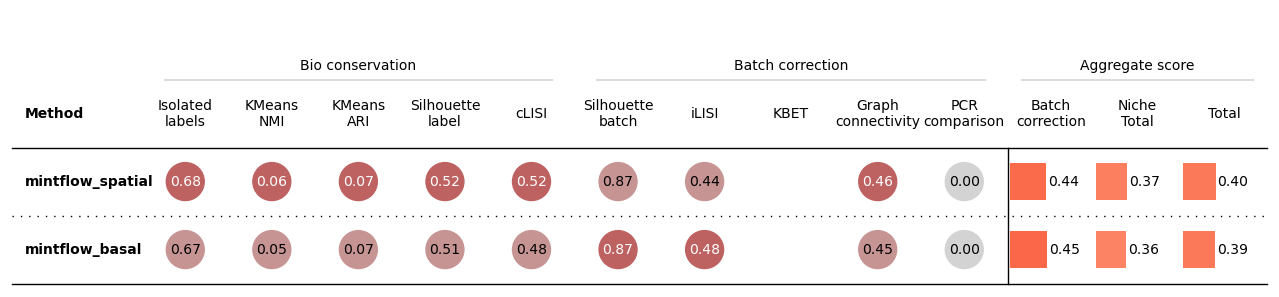

In [25]:
plot_results_table(omega_df, metric_cmap=gray_to_red, score_cmap=red_cmap, sort_col='Niche Total')